In [2]:
# Notebook for work analyzing the validity of different structural predictions using different software tools. Also work on determining
# how helpful custom MSAs could be (particularly for multimers). 

In [3]:
from utils import * 
import numpy as np
import shutil 
from matplotlib.lines import Line2D
import itertools
import os
import re

import sys 
sys.path.append('/home/prichter/Documents/banfield/betazoid/scripts/')
from scripts.msa import msa_main

%load_ext autoreload 
%autoreload 2


In [4]:
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/' # Directory name to match what is required on biotite.
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output' # Directory name to match what is required on biotite.


In [35]:
MIN_LENGTH = 30

genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()

# https://pmc.ncbi.nlm.nih.gov/articles/PMC9710616/
# print(f'Discarding {(genes_df.seq.apply(len) < MIN_LENGTH).sum()} proteins with length < {MIN_LENGTH} aa.') # Because structures can become untrustworthy.
# genes_df = genes_df[genes_df.seq.apply(len) >= MIN_LENGTH].copy()


In [6]:
level_1_conserved_cluster_ids = [8, 7, 0, 4, 5, 6, 1, 3, 2]
level_2_conserved_cluster_ids = [9, 12, 10, 13, 11]
level_3_conserved_cluster_ids = [18, 42, 33, 25, 17, 19, 20, 21, 50, 31, 40, 27, 34, 15, 14, 54, 24, 23, 41, 39, 57, 47, 48, 51, 45, 35, 49, 28, 62, 29]

conserved_cluster_ids = dict()
conserved_cluster_ids[1] = level_1_conserved_cluster_ids
conserved_cluster_ids[2] = level_2_conserved_cluster_ids
conserved_cluster_ids[3] = level_3_conserved_cluster_ids

conserved_cluster_gene_ids = dict()
conserved_cluster_gene_ids[1] = genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].index.values
conserved_cluster_gene_ids[2] = genes_df[genes_df.cluster_id.isin(level_2_conserved_cluster_ids)].index.values
conserved_cluster_gene_ids[3] = genes_df[genes_df.cluster_id.isin(level_3_conserved_cluster_ids)].index.values

for level, gene_ids in conserved_cluster_gene_ids.items():
    FASTAFile.from_df(genes_df.loc[gene_ids]).write(f'../data/genes/level_{level}_conserved_clusters.faa')

In [ ]:
# First want to evaluate the quality of the ColabFold structures. 
COLABFOLD_DIR = '../data/genes/colabfold/'

gene_ids =  pd.read_csv('../data/genes/genes.csv', index_col=0).index.values # All gene IDs before filtering for length, etc.i
paths = [os.path.join(COLABFOLD_DIR, get_genome_id(gene_id), gene_id) for gene_id in gene_ids]

# ColabFold does not use JackHMMer like AlphaFold2, and instead uses MMseqs. As a result, 
# the MSAs might not be as deep. Rather than using ColabFold as a first pass, it might be better to try ESMFold.

colabfold_metadata_df = get_fold_metadata(paths, output_path='analysis-1-structs_colabfold_metadata.csv', parser=ColabFoldOutput)
colabfold_metadata_df = colabfold_metadata_df.set_index('name')
colabfold_metadata_df['msa_num_seqs'] -= 2 # Adjust because the query is included twice.
colabfold_metadata_df['cluster_id'] = colabfold_metadata_df.index.map(genes_df.cluster_id)
colabfold_metadata_df['plddts_best_model'] = colabfold_metadata_df.plddts_best_model.apply(ast.literal_eval)


In [39]:
# To determine if a Foldseek result should be trusted, it seems reasonable to require that at least 50 residues with a pLDDT > 70. 
# I think using pTM as a filter would be a mistake, as even local structural matches are interesting. 

# ChatGPT gave me this paper as having a potentially useful methodology to follow: https://www.frontiersin.org/journals/parasitology/articles/10.3389/fpara.2023.1162697/full 
# The authors used pLDDT cutoff of 70 (over the whole protein), and an additional filter on the aligned region. 

def is_valid_structure(plddts:list, min_plddt:float=70, window_size:int=50, step_size:int=3):
    '''Determines if a structure prediction is sufficient for meaningful Foldseek results.
     
    :param plddts: Per-residue pLDDT from ColabFold output. 
    :param min_plddt: The minimum average pLDDT required to consider the structure prediction for a window to be "valid."
    :param window_size
    '''
    if len(plddts) < window_size:
        return False 
    for i in range(0, len(plddts) - window_size + 1, step_size):
        if np.mean(plddts[i:i + window_size]) > min_plddt:
            return True 
    return False

colabfold_metadata_df['valid_structure'] = colabfold_metadata_df.plddts_best_model.apply(is_valid_structure)
colabfold_metadata_df['level_1_conserved'] = colabfold_metadata_df.cluster_id.isin(level_1_conserved_cluster_ids)
colabfold_metadata_df['level_2_conserved'] = colabfold_metadata_df.cluster_id.isin(level_2_conserved_cluster_ids)
colabfold_metadata_df['level_3_conserved'] = colabfold_metadata_df.cluster_id.isin(level_3_conserved_cluster_ids)

print('Number of structures which could produce meaningful Foldseek hits:', colabfold_metadata_df.valid_structure.sum(), 'out of', len(colabfold_metadata_df))
for i in range(1, 4):
    mask = colabfold_metadata_df[f'level_{i}_conserved']
    print(f'Number of level {i} conserved structures which could produce meaningful Foldseek hits:', colabfold_metadata_df[mask].valid_structure.sum(), 'out of', mask.sum())


foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/genes*') if ('genes-genes' not in path)])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)]

Number of structures which could produce meaningful Foldseek hits: 318 out of 1633
Number of level 1 conserved structures which could produce meaningful Foldseek hits: 47 out of 93
Number of level 2 conserved structures which could produce meaningful Foldseek hits: 14 out of 31
Number of level 3 conserved structures which could produce meaningful Foldseek hits: 31 out of 72


In [45]:
def is_valid_structure_hit(plddts:list, min_plddt:float=70, min_length:int=50, start:int=None, stop:int=None):
    '''Determines if a structure prediction is sufficient for meaningful Foldseek results.
     
    :param plddts: Per-residue pLDDT from ColabFold output. 
    :param min_plddt: The minimum average pLDDT required to consider the structure prediction for a window to be "valid."
    :param start: The start index of the aligned region. 
    :param stop: The end index of the aligned retgion.
    :param min_length
    '''
    return (np.mean(plddts[start:stop]) > min_plddt) and ((stop - start) > min_length)


# foldseek_search_df['query_plddts'] = foldseek_search_df.query_id.map(colabfold_metadata_df.plddts_best_model)
# foldseek_search_df['valid_structure_hit'] = foldseek_search_df.apply(lambda row : is_valid_structure_hit(row.query_plddts, start=row.query_start, stop=row.query_end), axis=1)

print('Number of gene IDs with meaningful Foldseek hits:', foldseek_search_df[foldseek_search_df.valid_structure_hit].query_id.nunique())


Number of gene IDs with meaningful Foldseek hits: 192


In [ ]:
figure_df = genes_df.copy()
figure_df = figure_df.merge(colabfold_metadata_df, right_index=True, left_index=True)


mask = (genes_df.cluster_id.isin(level_1_conserved_cluster_ids))
print('Total number of conserved genes (level 1):', mask.sum())
print('Number of conserved genes (level 1) with > 0 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 0)).sum())
print('Number of conserved genes (level 1) with > 10 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 10)).sum()) 

mask = (genes_df.cluster_id.isin(level_2_conserved_cluster_ids))
print('\nTotal number of conserved genes (level 2):', mask.sum())
print('Number of conserved genes (level 2) with > 0 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 0)).sum())
print('Number of conserved genes (level 2) with > 10 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 10)).sum()) 

mask = (genes_df.cluster_id.isin(level_3_conserved_cluster_ids))
print('\nTotal number of conserved genes (level 3):', mask.sum())
print('Number of conserved genes (level 3) with > 0 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 0)).sum())
print('Number of conserved genes (level 3) with > 10 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 10)).sum()) 

mask = (~genes_df.cluster_id.isin(level_3_conserved_cluster_ids + level_2_conserved_cluster_ids + level_1_conserved_cluster_ids))
print('\nTotal number of non-conserved genes:', mask.sum())
print('Number of non-conserved genes with > 0 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 0)).sum())
print('Number of non-conserved genes with > 10 sequences in the ColabFold MSA:', (mask & (figure_df.msa_num_seqs > 10)).sum()) 

Total number of conserved genes (level 1): 93
Number of conserved genes (level 1) with > 0 sequences in the ColabFold MSA: 61
Number of conserved genes (level 1) with > 10 sequences in the ColabFold MSA: 23

Total number of conserved genes (level 2): 31
Number of conserved genes (level 2) with > 0 sequences in the ColabFold MSA: 16
Number of conserved genes (level 2) with > 10 sequences in the ColabFold MSA: 8

Total number of conserved genes (level 3): 72
Number of conserved genes (level 3) with > 0 sequences in the ColabFold MSA: 24
Number of conserved genes (level 3) with > 10 sequences in the ColabFold MSA: 17

Total number of non-conserved genes: 924
Number of non-conserved genes with > 0 sequences in the ColabFold MSA: 41
Number of non-conserved genes with > 10 sequences in the ColabFold MSA: 25


In [ ]:
filters = dict()
filters['none'] = np.array([True] * len(genes_df))
filters['level_1_conserved_clusters'] = genes_df.cluster_id.isin(level_1_conserved_cluster_ids)
filters['prodigal_predicted'] = ~genes_df.prodigal_gene_id.isnull()

In [ ]:
# filter_ = filters['level_1_conserved_clusters']

# fig, ax = plt.subplots(figsize=(5, 4))

# sns.stripplot(figure_df[filter_].explode('ptms'), x='cluster_id', y='ptms', color='lightgray', ax=ax, alpha=0.5, label='pTM')
# sns.stripplot(figure_df[filter_], x='cluster_id', y='ptm_best_model', color='gray', ax=ax, edgecolor='black', linewidth=0.7, label='best model pTM')

# handles = [Line2D([], [], marker='o', linestyle='', color='lightgray', label='pTM')]
# handles += [Line2D([], [], marker='o', linestyle='', color='gray', label='best model pTM')]
# ax.legend(handles=handles)

# ax.set_ylabel('')
# ax.set_xlabel('cluster ID')
# ax.set_xticks(ax.get_xticks(), labels=[str(int(i)) for i in ax.get_xticks()])
# plt.show()



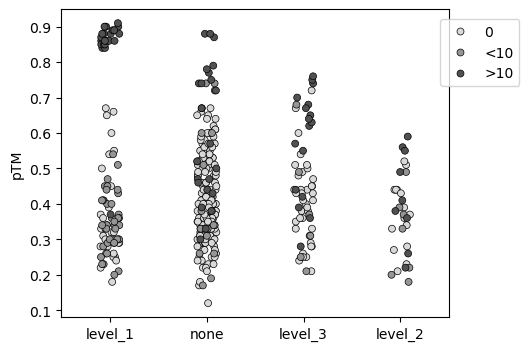

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

def get_msa_num_seqs_bin(n):
    if n == 0:
        return '0'
    elif n < 10:
        return '<10'
    else:
        return '>10'

figure_df['has_msa'] = figure_df.msa_num_seqs > 0
figure_df['length'] = figure_df.seq.apply(len)

categories = dict()
for level, gene_ids in conserved_cluster_gene_ids.items():
    categories[f'level_{level}'] = figure_df.index.isin(gene_ids)
categories, conditions = list(zip(*categories.items()))
figure_df['category'] = np.select(conditions, categories, default='none')
    
figure_df['msa_num_seqs_bin'] = figure_df.msa_num_seqs.apply(get_msa_num_seqs_bin)

# sns.stripplot(figure_df.sort_values('msa_num_seqs'), x='category', y='ptm_best_model', hue='msa_num_seqs_bin', palette='Grays', legend=True, edgecolor='black', linewidth=0.5)
sns.stripplot(figure_df[~figure_df.prodigal_gene_id.isnull()].sort_values('msa_num_seqs'), x='category', y='ptm_best_model', hue='msa_num_seqs_bin', palette='Grays', legend=True, edgecolor='black', linewidth=0.5)

ax.legend(bbox_to_anchor=(1.2, 0.99))

ax.set_xlabel('')
ax.set_ylabel('pTM')
plt.show()

In [ ]:
# get_alphafold_metadata(glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, 'orfm*')), output_path=f'analysis-1-structs-alphafold_metadata_{today}.csv')

# alphafold_metadata_df = get_alphafold_metadata(glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, 'orfm*')), 'analysis-1-structs-alphafold_metadata_08072026.csv')
# alphafold_metadata_df[alphafold_metadata_df.name == 'orfm.bz_8.1_215']


In [ ]:
# In order to generate better structures, I first tried running AlphaFold3 with MSAs containing the 9-11 confirmed homologs for the level_1_conserved_cluster genes. 
# This yielded some improvement, but confidence was still weak on some important proteins (e.g. cluster_1, cluster_3 multimers, etc.). I then decided to 
# build deeper MSAs using hits from ggKbase and Mgnify. 

In [ ]:
# In order to improve structure predictions further, attempted to recruit ggKbase homologs. 
GGKBASE_DIR = '../data/genes/ggkbase'

ggkbase_df = BLASTFile.from_file(os.path.join(GGKBASE_DIR, 'level_1_conserved_clusters.txt')).to_df()
ggkbase_df['query_coverage'] = ggkbase_df.alignment_length / ggkbase_df.query_length
ggkbase_df['target_coverage'] = ggkbase_df.alignment_length / ggkbase_df.target_length
ggkbase_df['query_cluster_id'] = ggkbase_df.query_id.map(genes_df.cluster_id)

print('Number of unique hits across all clusters before filtering:', ggkbase_df.target_id.nunique())

filters = dict()
filters['low_query_coverage'] = ggkbase_df.query_coverage < 0.75
filters['low_target_coverage'] = ggkbase_df.target_coverage < 0.75
filters['different_lengths'] = (np.abs(ggkbase_df.target_length - ggkbase_df.query_length) / ggkbase_df.query_length) > 0.5
filters['low_percent_identity'] = ggkbase_df.percent_identity < 0.2 # Probably pushing what would make sense for an MSA. 

ggkbase_df = apply_filters(filters, ggkbase_df)

seqs = FASTAFile.from_file(os.path.join(GGKBASE_DIR, 'level_1_conserved_clusters.faa')).to_df().seq
seqs = seqs.str.replace('*', '', regex=False) # Remove the '*' characters. 
seqs.index = seqs.index.str.split('|').str[0] # Remove the bin and project ID from the header. 
seqs = seqs.to_dict()

ggkbase_df['seq'] = ggkbase_df.target_id.map(seqs)
assert not np.any(ggkbase_df.seq.isnull()), f'{ggkbase_df.seq.isnull().sum()} out of {len(ggkbase_df)} ggKbase genes do not have a sequence.'

print('Number of unique sequences IDs across all clusters after filtering:', ggkbase_df.seq.nunique())
mask = ggkbase_df.seq.duplicated(keep='first') | ggkbase_df.target_id.duplicated(keep='first')
assert mask.sum() == ggkbase_df.seq.duplicated(keep='first').sum() , 'Not all entries with the same ID have the same sequence.'
ggkbase_df = ggkbase_df[~mask].copy().set_index('target_id')

for cluster_id, df in ggkbase_df.groupby('query_cluster_id'):
    print(f'\nCluster {int(cluster_id)} ({len(df)} unique hits)')
    print(f'Minimum percent identity: {100 * df.percent_identity.min():.2f}%')
    print(f'Minimum bit score: {df.bit_score.min()}')
    print(f'Maximum E-value: {df.e_value.max()}')

    # Write the cluster hits to a FASTA file. 
    path = os.path.join(GGKBASE_DIR, f'cluster_{int(cluster_id)}.faa')
    FASTAFile.from_df(df).write(path)


BLASTFile._from_ggkbase_text_file: Found 93 query entries in the file.
Number of unique hits across all clusters before filtering: 5994
apply_filters: 11144 entries removed by low_query_coverage.
apply_filters: 7524 entries removed by low_target_coverage.
apply_filters: 2890 entries removed by different_lengths.
apply_filters: 5 entries removed by low_percent_identity.
Number of unique sequences IDs across all clusters after filtering: 1759

Cluster 0 (1355 unique hits)
Minimum percent identity: 20.43%
Minimum bit score: 87.8
Maximum E-value: 9e-14

Cluster 1 (53 unique hits)
Minimum percent identity: 25.00%
Minimum bit score: 40.0
Maximum E-value: 2.5

Cluster 2 (49 unique hits)
Minimum percent identity: 27.05%
Minimum bit score: 38.9
Maximum E-value: 7.3

Cluster 3 (78 unique hits)
Minimum percent identity: 20.73%
Minimum bit score: 40.4
Maximum E-value: 8.0

Cluster 4 (38 unique hits)
Minimum percent identity: 26.67%
Minimum bit score: 36.2
Maximum E-value: 6.3

Cluster 5 (50 unique

In [ ]:
cluster_id = 1 
# It seems as though, in most cases, the more intensive AlphaFold search approach is not necessarily better.
max_msa_num_seqs = colabfold_metadata_df[colabfold_metadata_df.cluster_id == cluster_id].msa_num_seqs.max()
min_msa_num_seqs = colabfold_metadata_df[colabfold_metadata_df.cluster_id == cluster_id].msa_num_seqs.min()
print(f'Number of sequences in cluster {cluster_id} ColabFold MSAs:', min_msa_num_seqs, 'to', max_msa_num_seqs)

Number of sequences in cluster 1 ColabFold MSAs: 0 to 4


In [ ]:
MGNIFY_DIR = '../data/genes/mgnify'
MGNIFY_FIELDS = ['target_id', 'target_accession', 'target_length', 'query_id', 'query_length', 'e_value', 'bit_score', 'bias', 'domain_index', 'domain_count', 'cond_e_value', 'domain_ind_e_value', 'domain_bitscore', 'domain_bias', 'query_ali_start', 'query_ali_end', 'target_ali_start', 'target_ali_end', 'target_env_start', 'target_env_end', 'acc', 'description', 'tax_id', 'species']

load_mgnify_search_results = lambda path : pd.read_csv(path, sep='\t', header=0, names=MGNIFY_FIELDS) # These are the results from a profile HMM search (not BLAST).
mgnify_df = pd.concat([load_mgnify_search_results(path) for path in glob.glob(os.path.join(MGNIFY_DIR, f'cluster_{cluster_id}', '*tsv'))])

mgnify_df['alignment_length'] = mgnify_df.query_ali_end - mgnify_df.query_ali_start
mgnify_df['query_coverage'] = mgnify_df.alignment_length / mgnify_df.query_length
mgnify_df['target_coverage'] = mgnify_df.alignment_length / mgnify_df.target_length

print(f'Number of unique hits for cluster_{cluster_id} before filtering:', mgnify_df.target_id.nunique())

filters = dict()
filters['low_query_coverage'] = mgnify_df.query_coverage < 0.75
filters['low_target_coverage'] = mgnify_df.target_coverage < 0.75

mgnify_df = apply_filters(filters, mgnify_df)

seqs = pd.concat([FASTAFile.from_file(path).to_df() for path in glob.glob(os.path.join(MGNIFY_DIR, f'cluster_{cluster_id}', '*fa'))])
seqs = seqs.seq.to_dict()

mgnify_df['seq'] = mgnify_df.target_id.map(seqs)
assert not np.any(mgnify_df.seq.isnull()), f'{mgnify_df.seq.isnull().sum()} out of {len(mgnify_df)} ggKbase genes do not have a sequence.'

print(f'Number of unique hits for cluster_{cluster_id} after filtering:', mgnify_df.seq.nunique())
mask = mgnify_df.seq.duplicated(keep='first') | mgnify_df.target_id.duplicated(keep='first')
assert mask.sum() == mgnify_df.seq.duplicated(keep='first').sum() , 'Not all entries with the same ID have the same sequence.'
mgnify_df = mgnify_df[~mask].copy().set_index('target_id')

print(f'\nCluster {int(cluster_id)} ({len(mgnify_df)} unique hits)')
print(f'Minimum bit score: {mgnify_df.bit_score.min()}')
print(f'Maximum E-value: {mgnify_df.e_value.max()}')

# Write the cluster hits to a FASTA file. 
path = os.path.join(MGNIFY_DIR, f'cluster_{int(cluster_id)}.faa')
FASTAFile.from_df(mgnify_df).write(path)

no_mgnify_hits = len(mgnify_df) == 0


Number of unique hits for cluster_1 before filtering: 240
apply_filters: 660 entries removed by low_query_coverage.
apply_filters: 668 entries removed by low_target_coverage.
Number of unique hits for cluster_1 after filtering: 3

Cluster 1 (3 unique hits)
Minimum bit score: 18.9
Maximum E-value: 8.33


In [ ]:
database_df = [genes_df[genes_df.cluster_id == cluster_id][['seq']].copy()]

if not no_mgnify_hits:
    database_df += [FASTAFile.from_file(os.path.join(MGNIFY_DIR, f'cluster_{int(cluster_id)}.faa')).to_df()[['seq']]]
    
database_df += [FASTAFile.from_file(os.path.join(GGKBASE_DIR, f'cluster_{int(cluster_id)}.faa')).to_df()[['seq']]]
database_df = pd.concat(database_df)

query_gene_ids = genes_df[genes_df.cluster_id == cluster_id].index.tolist()
path = os.path.join('../data/genes/mmseqs/', f'cluster_{cluster_id}_database.faa')
FASTAFile.from_df(database_df).write(path)


msa_paths = msa_main(os.path.abspath(path), query_gene_ids=query_gene_ids, fmt='a3m', output_dir='../data/genes/mmseqs', database_dir='../data/genes/mmseqs/db')

msa_dereplicate: 50 representative sequences when clustered at 0.95 minimum identity.
msa_build_a3m: mmseqs createdb ../data/genes/mmseqs/cluster_1_database_reps.faa ../data/genes/mmseqs/db/database
msa_build_a3m: mmseqs search ../data/genes/mmseqs/db/database ../data/genes/mmseqs/db/database ../data/genes/mmseqs/db/database.out /home/prichter/Documents/banfield/betazoid/data/genes/mmseqs/tmp -s 9.5
msa_build_a3m: mmseqs align ../data/genes/mmseqs/db/database ../data/genes/mmseqs/db/database ../data/genes/mmseqs/db/database.out ../data/genes/mmseqs/db/database.aln
msa_build_a3m: mmseqs result2msa ../data/genes/mmseqs/db/database ../data/genes/mmseqs/db/database ../data/genes/mmseqs/db/database.aln ../data/genes/mmseqs/db/database.msa
msa_build_a3m: mmseqs unpackdb ../data/genes/mmseqs/db/database.msa ../data/genes/mmseqs --unpack-suffix .a3m
msa_build_a3m: Generated 50 total MSAs.
msa_build_a3m_cleanup: Removing 39 output MSAs which do not match a specified query ID.


In [ ]:
database_df = [genes_df[genes_df.cluster_id == cluster_id][['seq']].copy()]

if not no_mgnify_hits:
    database_df += [FASTAFile.from_file(os.path.join(MGNIFY_DIR, f'cluster_{int(cluster_id)}.faa')).to_df()[['seq']]]
    
database_df += [FASTAFile.from_file(os.path.join(GGKBASE_DIR, f'cluster_{int(cluster_id)}.faa')).to_df()[['seq']]]
database_df = pd.concat(database_df)

query_gene_ids = genes_df[genes_df.cluster_id == cluster_id].index.tolist()
path = os.path.join('../data/genes/muscle/', f'cluster_{int(cluster_id)}_database.faa')
FASTAFile.from_df(database_df).write(path)


# msa_paths = msa_main(os.path.abspath(path), query_gene_ids=query_gene_ids, fmt='afa', name=f'cluster_{int(cluster_id)}', output_dir='../data/genes/muscle')

In [ ]:
def get_msas_unpaired(gene_ids:list, dir_path:str='../data/genes/mmseqs'):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}



os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)

ALPHAFOLD_PARAMS = dict()
ALPHAFOLD_PARAMS['--num_diffusion_samples'] = 5 # Number of diffusion samples to generate, 5 by default. 
ALPHAFOLD_PARAMS['--num_recycles'] = 10 # Number of recycles to use during inference (refinement steps). 10 by default. 

for cluster_id, df in genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].groupby('cluster_id'):

    ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output'
    ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input'
    ALPHAFOLD_INPUT_DIR = os.path.join(ALPHAFOLD_INPUT_DIR, f'cluster_{int(cluster_id)}')

    for row in df.itertuples():

        msas = dict()
        msas['unpaired'] = get_msas_unpaired([row.Index])
        input = AlphaFoldInputFile(row.Index, dialect='alphafold3', num_seeds=3, version=2)
        input.add_seq(row.seq, paired_msa='', unpaired_msa=msas['unpaired'][row.Index], n=1)
        input.write(os.path.join(ALPHAFOLD_INPUT_DIR, row.Index + '.json'))


    cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(ALPHAFOLD_INPUT_DIR)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
    cmd += [f'{param} {value}' for param, value in ALPHAFOLD_PARAMS.items()]
    cmd = ' '.join(cmd)
    cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
    print(cmd)
# output_dirs = [os.path.join(ALPHAFOLD_OUTPUT_DIR, gene_id) for gene_id in conserved_cluster_gene_ids[1]]
# outputs = [AlphaFoldOutput(path) for path in output_dirs if os.path.exists(path)]
# print(f'Loaded {len(outputs)} AlphaFold3 structures.')




sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_0/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 5 --num_recycles 10"
sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_1/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 5 --num_recycles 10"
sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_2/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 5 --num_recycles 10"
sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_3/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 5 --num_recycles 10"
sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_4/ --model_dir

In [ ]:
# for gene_id in gene_ids:
#     print(f'biotite get /home/philippar/af_output/{gene_id}* {gene_id}', end='; ')

orfm.bz_3.1_50 (cluster_1): pTM difference -0.01	 ColabFold MSA has 3 sequences.


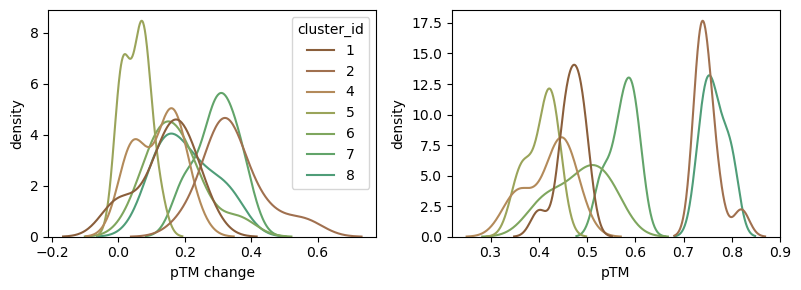

pTM range for cluster_0: 0.89 to 0.95
pTM range for cluster_1: 0.4 to 0.5
pTM range for cluster_2: 0.73 to 0.82
pTM range for cluster_3: 0.88 to 0.92
pTM range for cluster_4: 0.34 to 0.48
pTM range for cluster_5: 0.35 to 0.44
pTM range for cluster_6: 0.39 to 0.56
pTM range for cluster_7: 0.53 to 0.61
pTM range for cluster_8: 0.73 to 0.8


In [ ]:
figure_df = get_fold_metadata(glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, 'orfm*')), parser=AlphaFoldOutput, output_path=f'analysis-1-structs-alphafold_metadata.csv')
figure_df['ptm_best_model_colabfold'] = figure_df.name.map(colabfold_metadata_df.ptm_best_model)
figure_df['ptm_best_model_diff'] = figure_df.ptm_best_model - figure_df.ptm_best_model_colabfold
figure_df['msa_num_seqs_colabfold'] = figure_df.name.map(colabfold_metadata_df.msa_num_seqs)
figure_df['cluster_id'] = figure_df.name.map(genes_df.cluster_id).astype(int).astype(str)
figure_df = figure_df.set_index('name').sort_values('cluster_id')

for row in figure_df[figure_df.ptm_best_model_diff < 0].itertuples():
    print(f'{row.Index} (cluster_{row.cluster_id}): pTM difference {row.ptm_best_model_diff:.2f}\t ColabFold MSA has {row.msa_num_seqs_colabfold} sequences.')

fig, axes = plt.subplots(ncols=2, figsize=(8, 3))

cluster_ids = [str(i) for i in [1, 2, 4, 5, 6, 7, 8]]
# cluster_ids = None

if cluster_ids is None:
    cluster_ids = figure_df.cluster_id.unique()
mask = figure_df.cluster_id.isin(cluster_ids)

sns.kdeplot(figure_df[mask], x='ptm_best_model_diff', hue='cluster_id', common_norm=False, ax=axes[0], legend=True)
sns.kdeplot(figure_df[mask], x='ptm_best_model', hue='cluster_id', common_norm=False, ax=axes[1], legend=False)

axes[0].set_ylabel('density')
axes[1].set_ylabel('density')
axes[0].set_xlabel('pTM change')
axes[1].set_xlabel('pTM')


fig.tight_layout()
plt.show()

for cluster_id, df in figure_df.groupby('cluster_id'):
    print(f'pTM range for cluster_{cluster_id}: {df.ptm_best_model.min()} to {df.ptm_best_model.max()}')

In [ ]:
def copy_structures(paths:list, dir_:str, rename=lambda path : get_gene_id(path) + '.cif'):
    '''Copy structures at the specified paths to the output (destination) directory. If a rename function is provided, the file paths 
    are renamed in the destination directory. 
    
    :param paths:
    :param dir_: The destination directory for the copied structure files.
    '''
    os.makedirs(dir_, exist_ok=True)
    for path in paths:
        new_file_name = os.path.basename(path) if (rename is None) else rename(path)
        new_path = os.path.join(dir_, new_file_name)
        subprocess.run(f'cp {path} {new_path}', shell=True, check=True)

In [ ]:
# cluster_ids = [2, 4, 6, 7, 8] # These are the clusters whose structures were markedly improved by the custom MSA. 

gene_ids = genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].index.tolist()
output_dirs = [path for path in glob.glob('../data/genes/alphafold/af_output/*') if (get_gene_id(path) in gene_ids)]
outputs = [AlphaFoldOutput(path) for path in output_dirs]

In [ ]:
copy_structures([output.best_model_path for output in outputs], '../data/genes/foldseek/query/level_1_conserved_clusters/')

FOLDSEEK_FIELDS = 'query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,taxid,taxname,taxlineage,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob'
FOLDSEEK_DATABASE_NAMES = ['alphafold_swissprot', 'alphafold_uniprot', 'bfvd', 'pdb']
FOLDSEEK_DATABASE_PATHS = [f'/shared/db/foldseek/latest/db/{name}' for name in FOLDSEEK_DATABASE_NAMES]
FOLDSEEK_OUTPUT_PATHS = [f'/home/philippar/foldseek/level_1_conserved_clusters-{name}.tsv' for name in FOLDSEEK_DATABASE_NAMES]
FOLDSEEK_QUERY_PATH = '/home/philippar/foldseek/query/level_1_conserved_clusters/'

FOLDSEEK_PARAMS = dict()
FOLDSEEK_PARAMS['--alignment-type'] = '1'
FOLDSEEK_PARAMS['-a'] = ''
FOLDSEEK_PARAMS['--format-output'] = f'"{FOLDSEEK_FIELDS}"'

for database_path, output_path in zip(FOLDSEEK_DATABASE_PATHS, FOLDSEEK_OUTPUT_PATHS):
    cmd = [f'foldseek easy-search {FOLDSEEK_QUERY_PATH} {database_path} {output_path} tmp'] + [' '.join(params) for params in FOLDSEEK_PARAMS.items()] 
    cmd = ' '.join(cmd)
    print(cmd)

foldseek easy-search /home/philippar/foldseek/query/level_1_conserved_clusters/ /shared/db/foldseek/latest/db/alphafold_swissprot /home/philippar/foldseek/level_1_conserved_clusters-alphafold_swissprot.tsv tmp --alignment-type 1 -a  --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,taxid,taxname,taxlineage,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"
foldseek easy-search /home/philippar/foldseek/query/level_1_conserved_clusters/ /shared/db/foldseek/latest/db/alphafold_uniprot /home/philippar/foldseek/level_1_conserved_clusters-alphafold_uniprot.tsv tmp --alignment-type 1 -a  --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,taxid,taxname,taxlineage,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"
foldseek easy-search /home/philipp

In [ ]:
# Run DSSP on all the new structures to get encodings of their structures. 
DSSP_OUTPUT_DIR = '../data/genes/dssp/'
DSSP_INPUT_DIR = '../data/genes/dssp/input/level_1_conserved_clusters/'
os.makedirs(DSSP_INPUT_DIR, exist_ok=True)

copy_structures([output.best_model_path for output in outputs], DSSP_INPUT_DIR)

for path in glob.glob(os.path.join(DSSP_INPUT_DIR, '*')):
    gene_id = get_gene_id(path)
    output_path = os.path.join(DSSP_OUTPUT_DIR, f'{gene_id}.dssp')
    if not os.path.exists(output_path):
        subprocess.run(f'mkdssp {path} {output_path} --output-format dssp', shell=True, check=True)